# Calculating Lipinski Descriptors
Christopher Lipinski, a scientist at Pfizer, developed a set of rules for evaluating the drug-likeness of a compound - predicting if a molecule is likely to be orally active and bioavailable in humans. 
The rules is defined by the Absorption, Distribution, Metabolism and Excretion (ADME), also known as the pharmacokinetic profile. 
Lipinski's **Rule of Five** (Ro5)  

The Lipinski's Rules care strictly about the Absorption aspect of ADME (Absorption, Distribution, Metabolism, and Excretion):
When a pill is swallowed it must survive the stomach's acidity, remain adequately dissolved, and cross the non-polar cellular membranes of the gut lining to reach the bloodstream.
- Molecules that are too large (high molecular weight) move too slowly to easily penetrate membranes.
- Molecules with too many Hydrogen bond donors/acceptors bind too tightly to water and refuse to enter the non-polar membrane.
- Molecules with a Log P over 5 are highly water-insoluble (too greasy) and will not dissolve properly in the GI tract.

Compounds are generally considered to possesses favorable properties for oral administration if they do not violate more than one of the following criteria:

Molecular weight < 500 Dalton (g/mol)
Octanol-water partition coefficient (LogP) < 5 (a drug's octanol-water partition coefficient)
Hydrogen bond donors < 5 (total count of N-H and O-H bonds)
Hydrogen bond acceptors < 10 (total count of Nitrogen and Oxygen atoms)
> ----------------------------------------------------------------------------------------------------------------------------------------------------------------
> **NOTES:** 
> - Not an absolute physical law - it is common for for classes of certain drugs to violate 2+ rules and still be viable for oral administration.
> - Transporters: The rule assumes passive diffusion across membranes. Many large drugs trick the body into absorbing them by utilizing active transport proteins
> - Specialized Drugs: Drugs targeting the central nervous system (CNS), peptide-based drugs, and large natural products often fall outside the Rule of Five.
> ----------------------------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
import pandas as pd
import numpy as np
from openbabel import pybel
from IPython.display import SVG
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem, Crippen
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from chembl_webresource_client.new_client import new_client
IPythonConsole.ipython_useSVG = True
#import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style("whitegrid")
RANDOM_SEED = 42

In [3]:
df = pd.read_csv('acetylcholinesterase_activity_03_classes_defined.csv')
df.head(3)

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive


In [4]:
print(f"Rows: {len(df):,}  |  Cols: {df.shape[1]}")
print(f"Unique compounds (raw SMILES): {df['canonical_smiles'].nunique():,}")

Rows: 7,175  |  Cols: 4
Unique compounds (raw SMILES): 7,175


In [5]:
# Split by '.', find the longest string, and create a Series
smiles = (
    df['canonical_smiles']
    .astype(str)
    .str.split('.')
    .apply(lambda x: max(x, key=len))
)

# Set the name of the Series
smiles.name = 'canonical_smiles'
print(smiles.head(3))

0                CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1
1           O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1
2    CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1
Name: canonical_smiles, dtype: str


## Calculate Lipinski Descriptors
Extract the following from the smiles string using rdkit.chem:
- Molecular Weight
- LogP
- Num H bond donors
- Num H bond acceptors
- Topological Polar Surface Area
- Num Rotatable Bonds


In [6]:

def get_lipinski_descriptors(smiles, verbose=False) -> dict:
    """
    Calculate Lipinski's Rule of Five descriptors for a given SMILES string.
    Parameters:
    smiles (str): The SMILES string of the molecule.
    verbose (bool): Whether to print verbose output.

    Returns:
    dict: A dictionary containing the calculated descriptors.
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        if verbose:
            print(f"Invalid SMILES: {smiles}")
        return None
    return {
        "MW": Descriptors.MolWt(mol),                                   # Molecular Weight
        "LogP": Descriptors.MolLogP(mol),                               # Lipophilicity - the logarithm of the partition coefficient
        "NumHDonors": Descriptors.NumHDonors(mol),                      # Number of hydrogen bond donors
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),                # Number of hydrogen bond acceptors
        "TPSA": Descriptors.TPSA(mol),                                  # Topological Polar Surface Area
        "RotatableBonds": Descriptors.NumRotatableBonds(mol)            # Number of rotatable bonds
    }

In [7]:
print(get_lipinski_descriptors("CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1"))

{'MW': 312.32500000000005, 'LogP': 2.8032000000000004, 'NumHDonors': 0, 'NumHAcceptors': 5, 'TPSA': 66.49000000000001, 'RotatableBonds': 6}


In [8]:
# Drop rows where IC50 values are missing , zero, or negative
df = df.dropna(subset=['standard_value'])
df = df[df['standard_value'] > 0]

In [9]:
# Create a dataframe of Lipinski descriptors from canonical_smiles values
df_lipinski = df.apply(lambda row: get_lipinski_descriptors(row['canonical_smiles']), axis=1)
print(df_lipinski)


0       {'MW': 312.32500000000005, 'LogP': 2.803200000...
1       {'MW': 376.9130000000002, 'LogP': 4.5546000000...
2       {'MW': 426.8510000000001, 'LogP': 5.3574000000...
3       {'MW': 404.8450000000001, 'LogP': 4.7069000000...
4       {'MW': 346.33400000000006, 'LogP': 3.095300000...
                              ...                        
7170    {'MW': 449.2950000000001, 'LogP': 7.0491000000...
7171    {'MW': 356.81600000000003, 'LogP': 2.941100000...
7172    {'MW': 414.46500000000026, 'LogP': 3.032420000...
7173    {'MW': 415.3240000000002, 'LogP': 4.6573000000...
7174    {'MW': 601.2349999999999, 'LogP': 6.7360000000...
Length: 7174, dtype: object


In [10]:
#lipinski_colnames = ["MW", "LogP", "NumHDonors", "NumHAcceptors", "TPSA", "NumRotatableBonds"]
df_lipinski = pd.DataFrame(df_lipinski.to_list())
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds
0,312.325,2.8032,0,5,66.49,6
1,376.913,4.5546,0,4,51.02,4
2,426.851,5.3574,0,4,51.02,4
3,404.845,4.7069,0,4,51.02,3
4,346.334,3.0953,0,5,60.25,3


In [11]:
df2 = pd.concat([df, df_lipinski], axis=1)
df2.head(3)

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active,312.325,2.8032,0.0,5.0,66.49,6.0
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active,376.913,4.5546,0.0,4.0,51.02,4.0
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive,426.851,5.3574,0.0,4.0,51.02,4.0


## Convert IC50 to pIC50
Convert IC50 to negative logarithmic scale -log10(IC50) to improve uniformity of distribution.

- Take the IC50 values from the standard_value column and converts it from nM to M by multiplying the value by 10^-9
- Take the molar value and apply -log10
- Delete the standard_value column and create a new pIC50 column

NOTE: Vals > 100,000,000 will be reduced to 100,000,000 to prevent the -log value becoming negative.

In [12]:
# Helper function
# For each value in standard_value:
## Standardise the standard_value such that vals > 100,000,000 are replaced with 100,000,000
## Convert the standard_value from nM to M --> standard_value*10^-9
## Take the -log10 of the converted value --> -np.log10(standard_value*10^-9)

def convert_ic50_to_pic50(df: pd.DataFrame, ic50_col: str = 'standard_value', pic50_col: str = 'pIC50') -> pd.DataFrame:
    """
    Convert IC50 values to pIC50 values.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    ic50_col (str): The column name for the IC50 values.
    pic50_col (str): The column name for the pIC50 values.

    Returns:
    pd.DataFrame: The DataFrame with the pIC50 column added.

    Constraints: IC50 values must be positive numbers.
    """
    ic50 = pd.to_numeric(df[ic50_col], errors='coerce')
    # Standardise the standard_value such that vals > 100,000,000 are replaced with 100,000,000
    ic50.clip(lower=None, upper=1e8, inplace=True)
    df[pic50_col] = -np.log10(ic50 * 1e-9)
    return df

In [13]:
# Convert IC50 values to pIC50 values and add pic50 series to dataframe
df2 = convert_ic50_to_pic50(df2)

In [14]:
df2.head(3)

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active,312.325,2.8032,0.0,5.0,66.49,6.0,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active,376.913,4.5546,0.0,4.0,51.02,4.0,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive,426.851,5.3574,0.0,4.0,51.02,4.0,4.301030


In [15]:
df2.drop('standard_value', axis=1, inplace=True)
df2.head(2)

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.8032,0.0,5.0,66.49,6.0,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.5546,0.0,4.0,51.02,4.0,7.000000


In [16]:
df2.pIC50.describe()

count    7174.000000
mean        5.815051
std         1.549445
min         1.000000
25%         4.783571
50%         5.617084
75%         6.798603
max        14.301030
Name: pIC50, dtype: float64

In [ ]:
#df2.to_csv('acetylcholinesterase_activity_04_pic50.csv')

In [19]:
df2['class'].value_counts()

class
active          2993
inactive        2357
intermediate    1824
Name: count, dtype: int64

In [20]:
# Drop intermediate items from the dataframe
df3 = df2[df2['class'] != 'intermediate']
df3.reset_index(drop=True, inplace=True)

In [21]:
df3['class'].value_counts()

class
active      2993
inactive    2357
Name: count, dtype: int64

In [22]:
df3.to_csv('acetylcholinesterase_activity_05_pic50_filtered.csv', index=False)

## EDA: Chemical Space Analysis via Lipinski Descriptors

```python
{
    "MW": Descriptors.MolWt(mol),                                   # Molecular Weight
    "LogP": Descriptors.MolLogP(mol),                               # Lipophilicity - the logarithm of the partition coefficient
    "NumHDonors": Descriptors.NumHDonors(mol),                      # Number of hydrogen bond donors
    "NumHAcceptors": Descriptors.NumHAcceptors(mol),                # Number of hydrogen bond acceptors
    "TPSA": Descriptors.TPSA(mol),                                  # Topological Polar Surface Area
    "RotatableBonds": Descriptors.NumRotatableBonds(mol)            # Number of rotatable bonds
}
```

In [23]:
import seaborn as sns
sns.set_theme(style='ticks')
import matplotlib.pyplot as plt

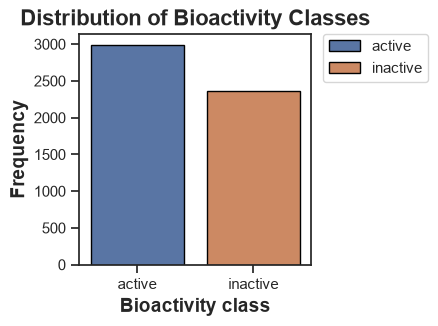

In [41]:
plt.figure(figsize=(3, 3))

sns.countplot(x='class', data=df3, edgecolor='black', hue='class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.title('Distribution of Bioactivity Classes', fontsize=16, fontweight='bold')
plt.show()

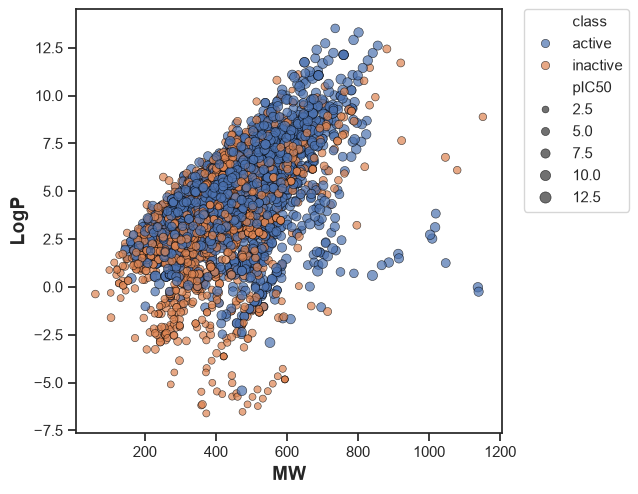

In [32]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df3, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.show()

### LogP
Measure of liphocility (how easy a molecule dissolves in fats/oils/lipids compared to water)

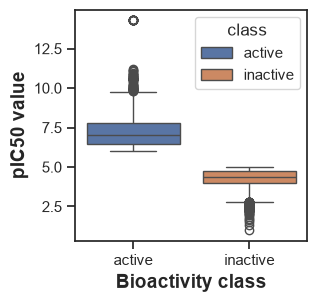

In [42]:

plt.figure(figsize=(3, 3))
sns.boxplot(x = 'class', y = 'pIC50', data = df3, hue='class')
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')
plt.show()

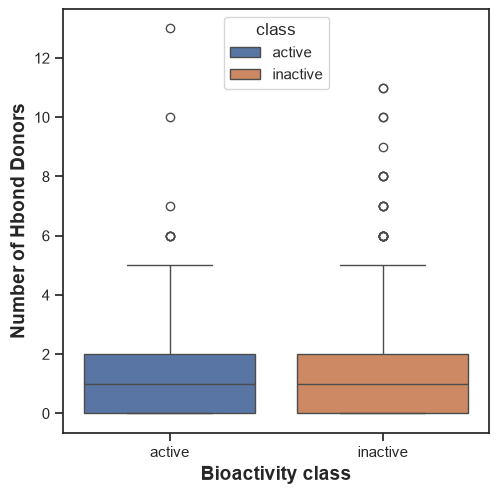

In [34]:
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x = 'class', y = 'NumHDonors', data = df3, hue='class')
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Number of Hbond Donors', fontsize=14, fontweight='bold')
plt.show()

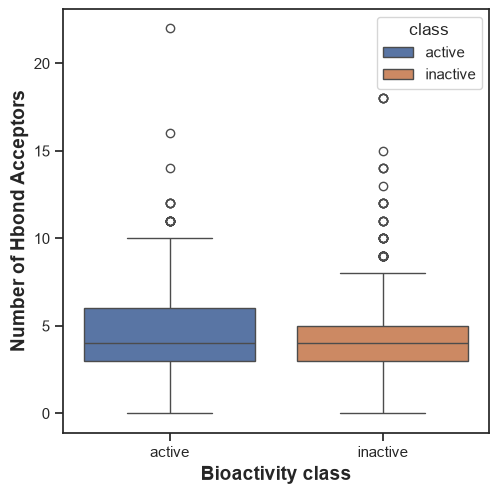

In [35]:
plt.figure(figsize=(5.5, 5.5))
sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df3, hue='class')
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Number of Hbond Acceptors', fontsize=14, fontweight='bold')
plt.show()

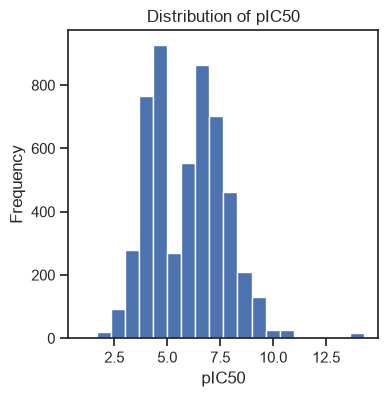

In [37]:
plt.figure(figsize=(4, 4))
x = df3['pIC50']
plt.hist(x, bins=20)
plt.title('Distribution of pIC50')
plt.xlabel('pIC50')
plt.ylabel('Frequency')
plt.show()

In [43]:
df3.columns

Index(['molecule_chembl_id', 'canonical_smiles', 'class', 'MW', 'LogP',
       'NumHDonors', 'NumHAcceptors', 'TPSA', 'RotatableBonds', 'pIC50'],
      dtype='str')

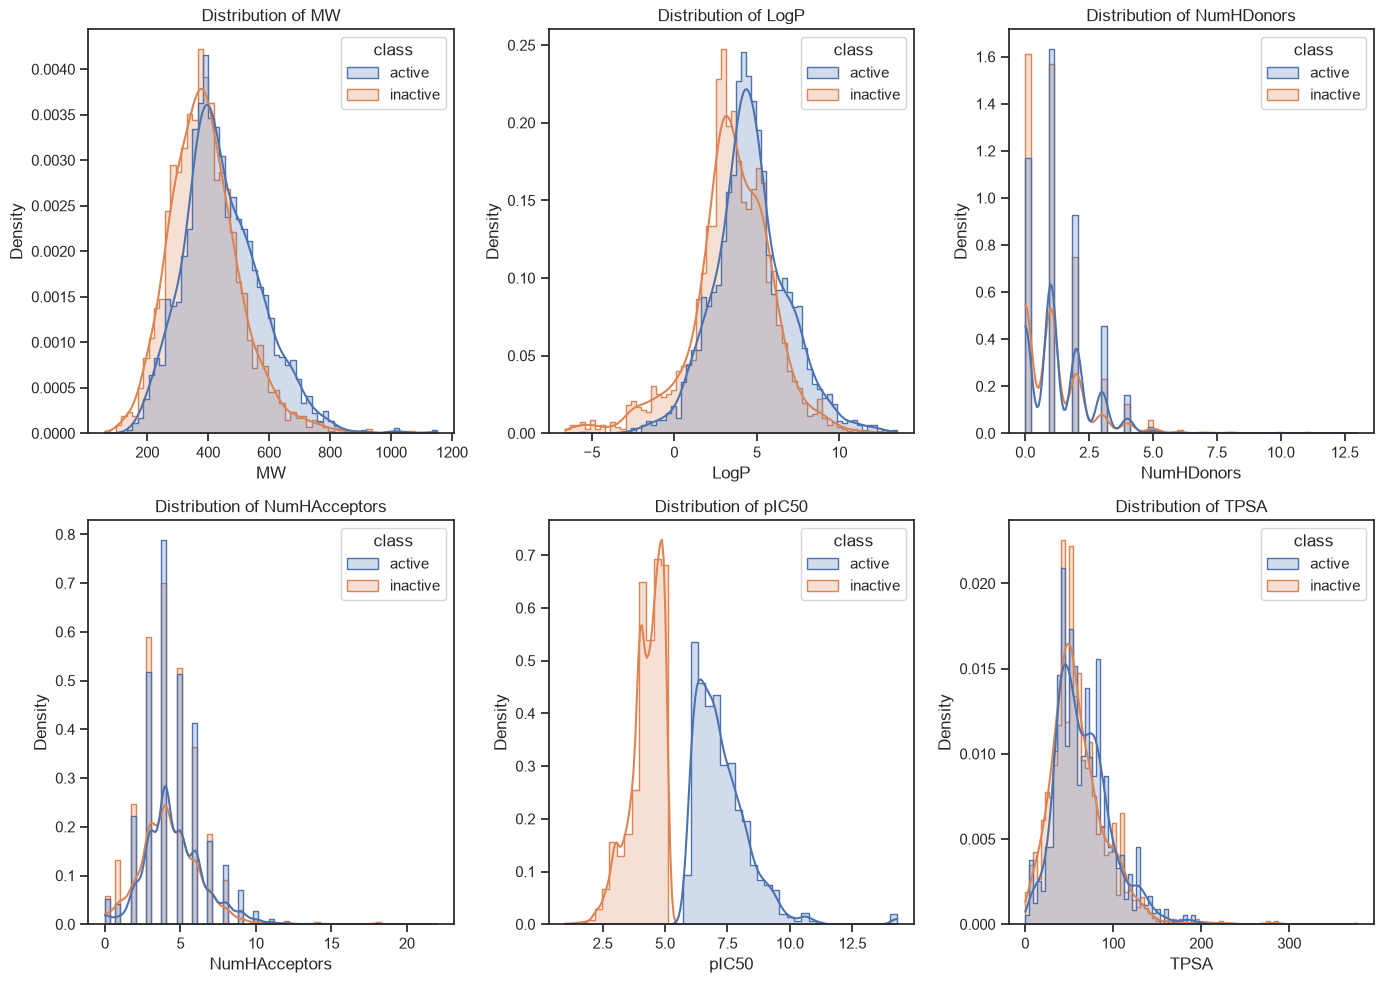

In [46]:
# Test for Gausiannity:
## Evaluate the distribution of Lipinski descriptor values and pic50 for each bioactivity class.

# List of your Lipinski descriptor column names
fields = ['MW', 'LogP','NumHDonors', 'NumHAcceptors', 'pIC50', 'TPSA']

# Create a grid of subplots (e.g., 2 rows, 2 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 10))
axes = axes.flatten()  # Flatten the 2D grid into a 1D array for easy looping

for idx, field_name in enumerate(fields):
    # Plot histogram with KDE overlay, color-coded by bioactivity
    sns.histplot(
        data=df3, 
        x=field_name, 
        hue='class',        # Assumes column contains 'active' or 'inactive'
        kde=True,           # Adds the Kernel Density Estimate line
        element='step',     # Distinct boundaries for overlapping bars
        stat='density',     # Normalizes the bars so different group sizes can be compared
        common_norm=False,  # Normalizes each bioactivity group independently
        ax=axes[idx]
    )
    axes[idx].set_title(f'Distribution of {field_name}')
    axes[idx].set_xlabel(field_name)
    axes[idx].set_ylabel('Density')

plt.tight_layout()
plt.show()


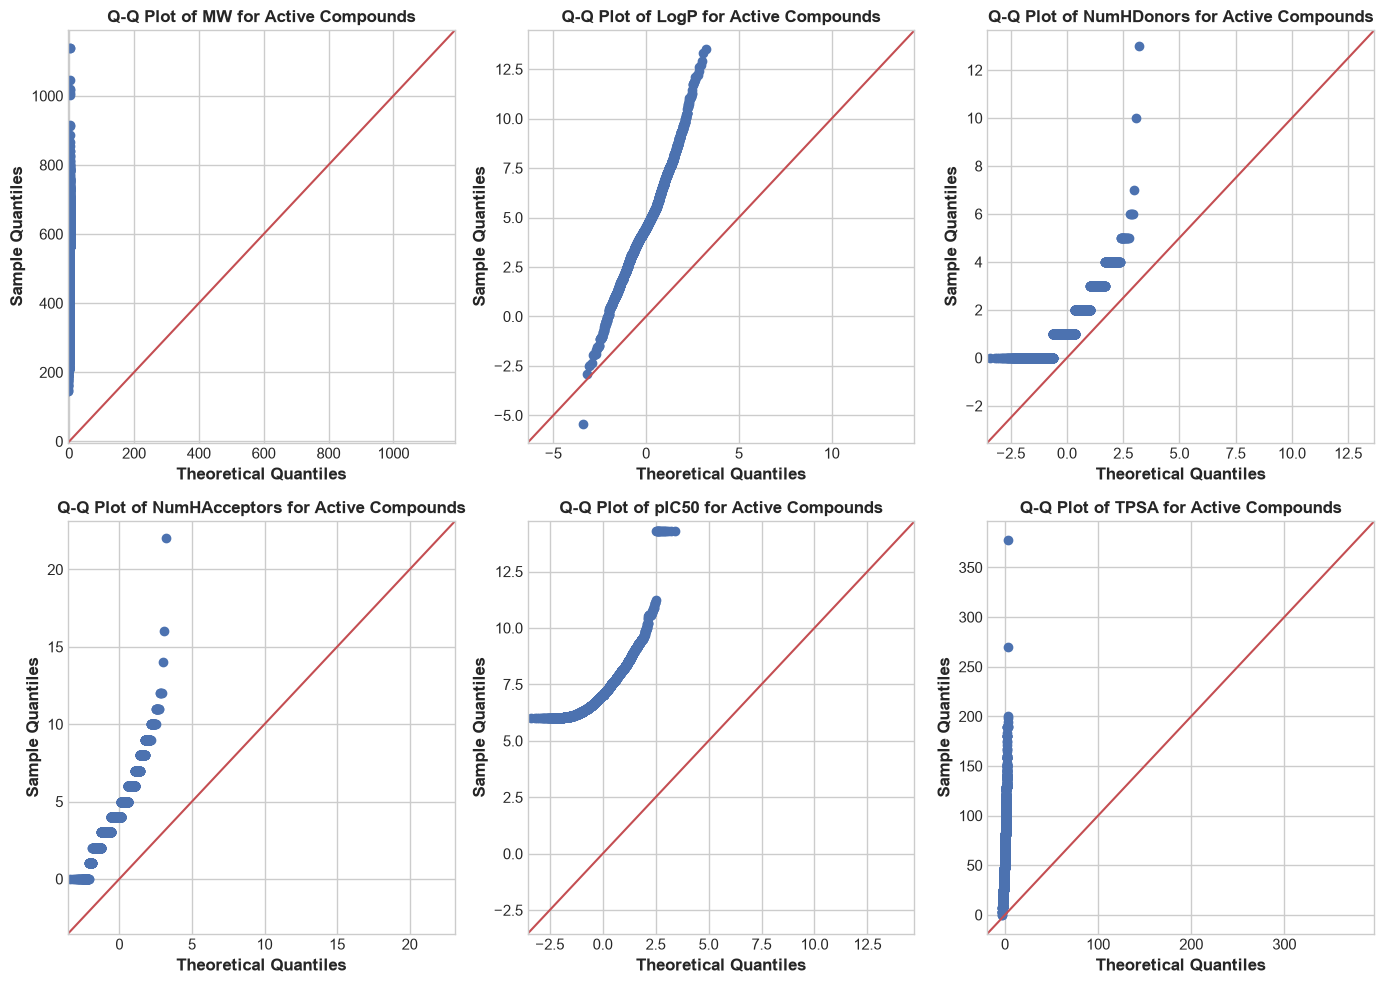

In [66]:
# Q-Q plots for each field
##  If your data is Gaussian, the points will fall perfectly along the straight diagonal 45-degree reference line. 
##  If the points curve away from the line at the ends (tails), the data is non-Gaussian.
import statsmodels.api as sm
fields = ['MW', 'LogP','NumHDonors', 'NumHAcceptors', 'pIC50', 'TPSA']
actives, inactives = df3[df3['class'] == 'active'], df3[df3['class'] == 'inactive']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 10))
axes = axes.flatten()

for idx, field_name in enumerate(fields):
    sm.qqplot(actives[field_name], line='45', ax=axes[idx])
    axes[idx].set_title(f'Q-Q Plot of {field_name} for Active Compounds', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Theoretical Quantiles', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Sample Quantiles', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

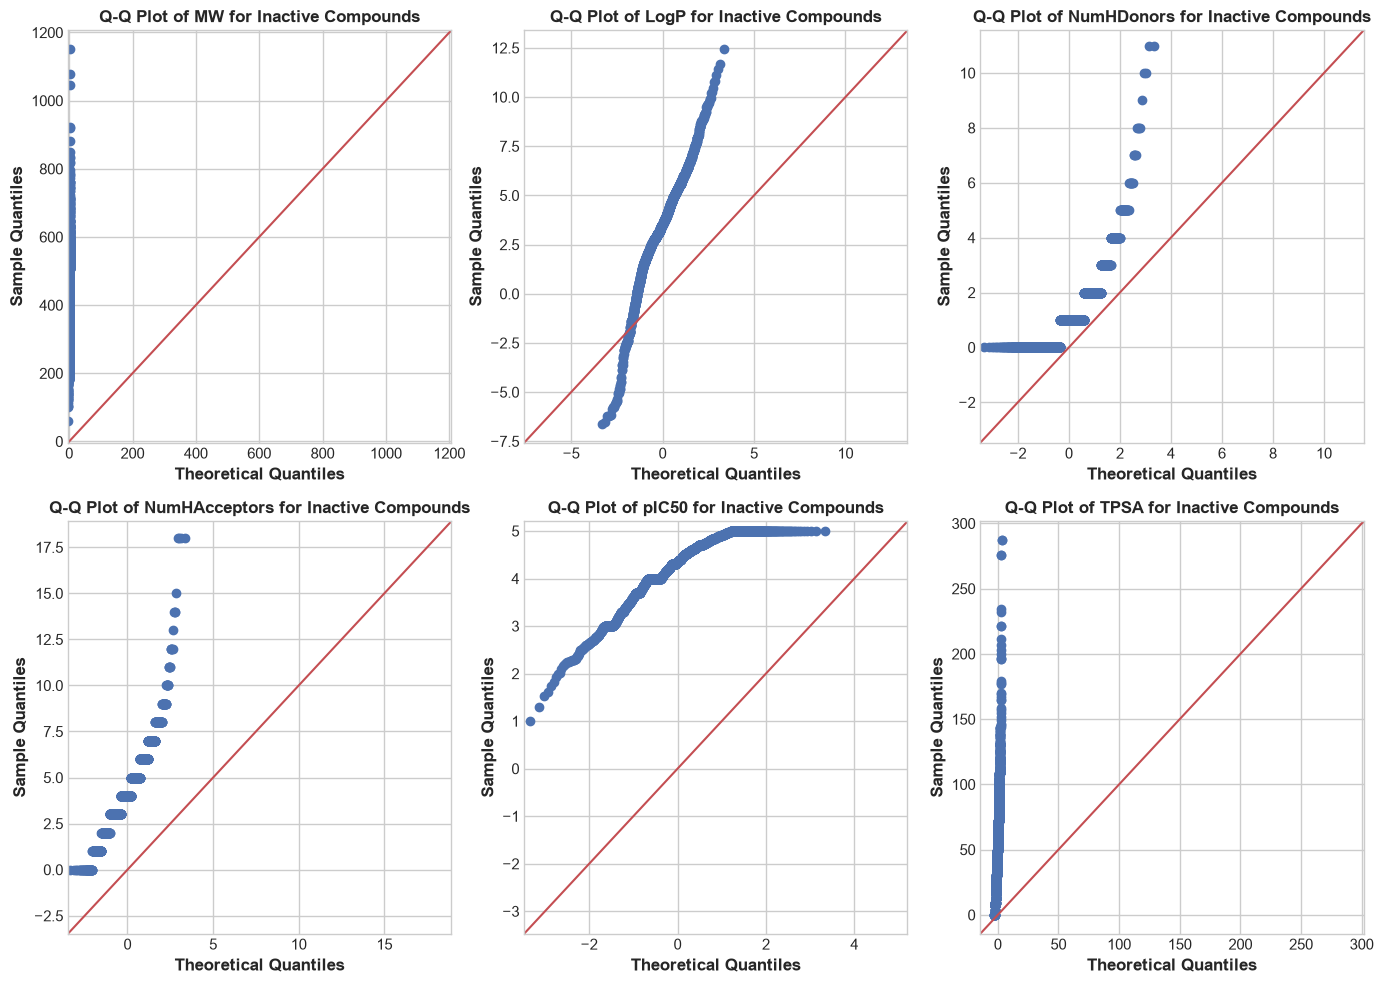

In [65]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 10))
axes = axes.flatten()

for idx, field_name in enumerate(fields):
    sm.qqplot(inactives[field_name], line='45', ax=axes[idx])
    axes[idx].set_title(f'Q-Q Plot of {field_name} for Inactive Compounds', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Theoretical Quantiles', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Sample Quantiles', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import scipy.stats as stats

# Example usage of scipy.stats for statistical tests
# For instance, to perform a t-test between two groups:
# t_stat, p_value = stats.ttest_ind(actives['LogP'], inactives['LogP'])

fields = ['MW', 'LogP','NumHDonors', 'NumHAcceptors', 'pIC50', 'TPSA']
actives, inactives = df3[df3['class'] == 'active'], df3[df3['class'] == 'inactive']

### Interpretation
Visual inspection

Histogram: a bell-shaped curve suggests normality.
Q-Q plot: if points fall close to a straight line, the data are approximately Gaussian.
Statistical tests

Shapiro-Wilk test: commonly used for small to medium samples.
Anderson-Darling or Kolmogorov-Smirnov tests: also used, though they are stricter.
A p-value above 0.05 usually suggests you do not reject normality, but this does not prove the data are Gaussian.
Summary statistics

Gaussian distributions are often symmetric, with skewness near 0 and kurtosis near 3.
Strong skewness or heavy tails suggest non-Gaussian behavior.
Practical rule

If the sample is large, visual methods are often more informative than a single hypothesis test, because tests can reject normality even for tiny deviations.

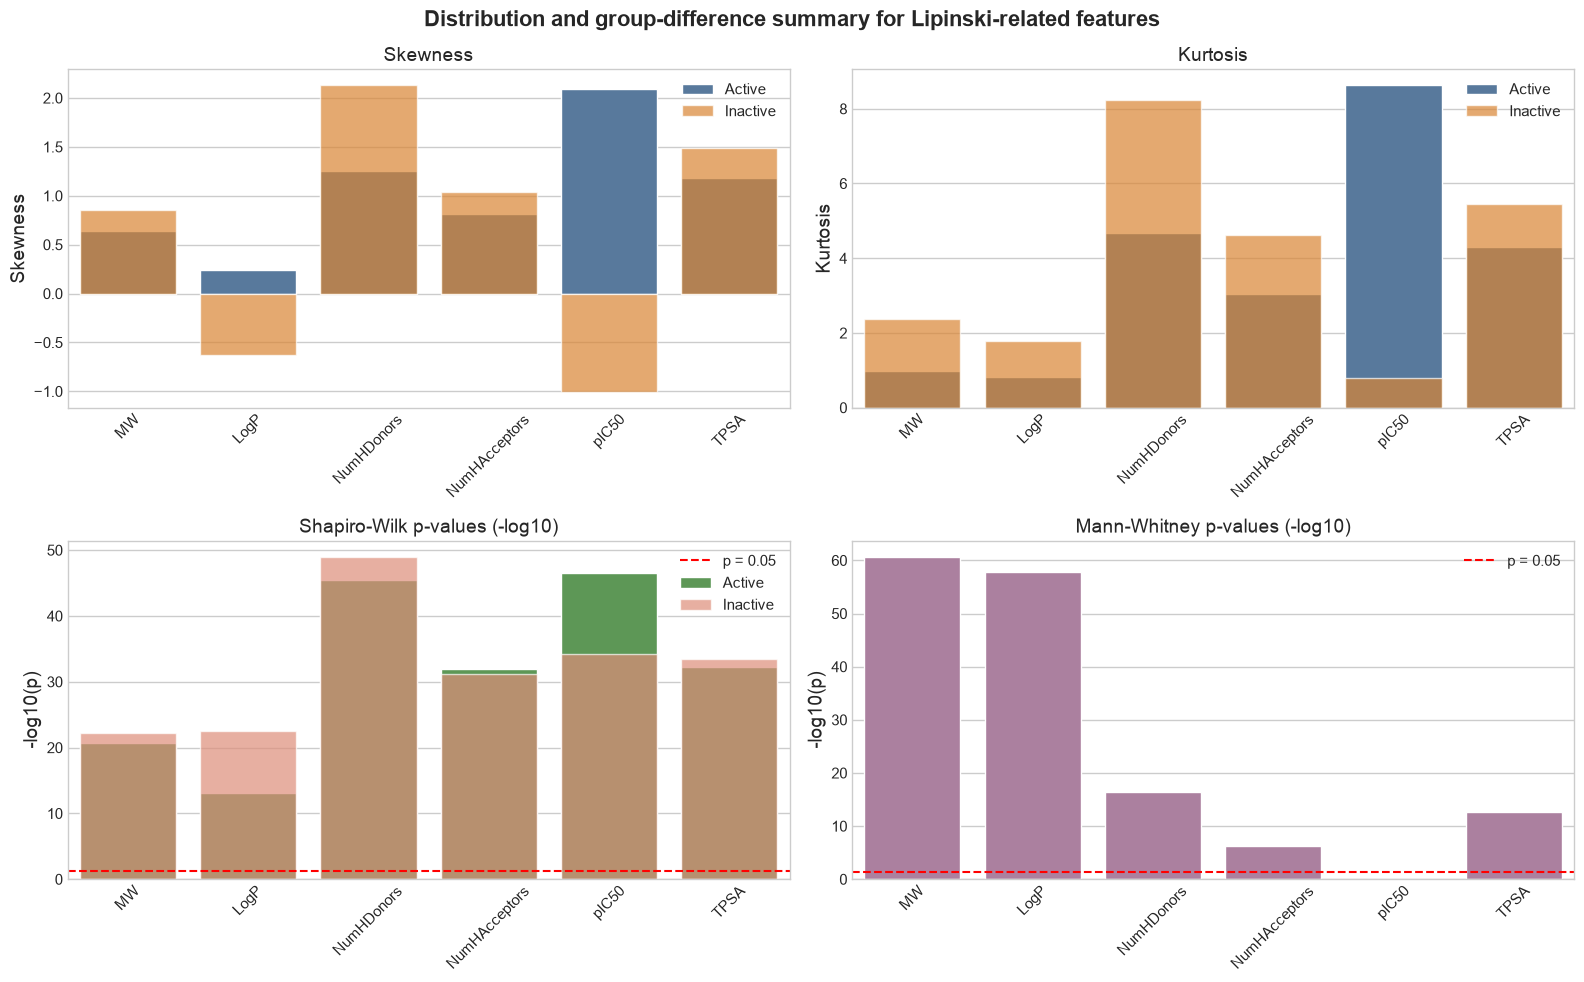

In [57]:
import scipy.stats as stats

features = ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50', 'TPSA']
active = df3[df3['class'] == 'active']
inactive = df3[df3['class'] == 'inactive']

rows = []

for feat in features:
    a = active[feat].dropna()
    i = inactive[feat].dropna()

    a_skew = a.skew() if len(a) > 2 else np.nan
    i_skew = i.skew() if len(i) > 2 else np.nan
    a_kurt = a.kurt() if len(a) > 3 else np.nan
    i_kurt = i.kurt() if len(i) > 3 else np.nan

    a_shapiro_p = stats.shapiro(a).pvalue if len(a) >= 3 else np.nan
    i_shapiro_p = stats.shapiro(i).pvalue if len(i) >= 3 else np.nan

    _, mw_p = stats.mannwhitneyu(a, i, alternative='two-sided') if len(a) >= 1 and len(i) >= 1 else (np.nan, np.nan)

    rows.append({
        'feature': feat,
        'active_skew': a_skew,
        'inactive_skew': i_skew,
        'active_kurt': a_kurt,
        'inactive_kurt': i_kurt,
        'active_shapiro_p': a_shapiro_p,
        'inactive_shapiro_p': i_shapiro_p,
        'mannwhitney_p': mw_p
    })

summary = pd.DataFrame(rows)

summary['active_shapiro_neglog10'] = -np.log10(summary['active_shapiro_p'].replace(0, np.nan))
summary['inactive_shapiro_neglog10'] = -np.log10(summary['inactive_shapiro_p'].replace(0, np.nan))
summary['mannwhitney_neglog10'] = -np.log10(summary['mannwhitney_p'].replace(0, np.nan))

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribution and group-difference summary for Lipinski-related features', fontsize=16, fontweight='bold')

# Skewness
sns.barplot(data=summary, x='feature', y='active_skew', color='#4C78A8', ax=axes[0, 0], label='Active')
sns.barplot(data=summary, x='feature', y='inactive_skew', color='#F58518', alpha=0.7, ax=axes[0, 0], label='Inactive')
axes[0, 0].set_title('Skewness')
axes[0, 0].set_ylabel('Skewness')
axes[0, 0].legend()

# Kurtosis
sns.barplot(data=summary, x='feature', y='active_kurt', color='#4C78A8', ax=axes[0, 1], label='Active')
sns.barplot(data=summary, x='feature', y='inactive_kurt', color='#F58518', alpha=0.7, ax=axes[0, 1], label='Inactive')
axes[0, 1].set_title('Kurtosis')
axes[0, 1].set_ylabel('Kurtosis')

# Shapiro-Wilk p-values
sns.barplot(data=summary, x='feature', y='active_shapiro_neglog10', color='#54A24B', ax=axes[1, 0], label='Active')
sns.barplot(data=summary, x='feature', y='inactive_shapiro_neglog10', color='#EE846A', alpha=0.7, ax=axes[1, 0], label='Inactive')
axes[1, 0].axhline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')
axes[1, 0].set_title('Shapiro-Wilk p-values (-log10)')
axes[1, 0].set_ylabel('-log10(p)')
axes[1, 0].legend()

# Mann-Whitney p-values
sns.barplot(data=summary, x='feature', y='mannwhitney_neglog10', color='#B279A2', ax=axes[1, 1])
axes[1, 1].axhline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')
axes[1, 1].set_title('Mann-Whitney p-values (-log10)')
axes[1, 1].set_ylabel('-log10(p)')
axes[1, 1].legend()

for ax in axes.flatten():
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


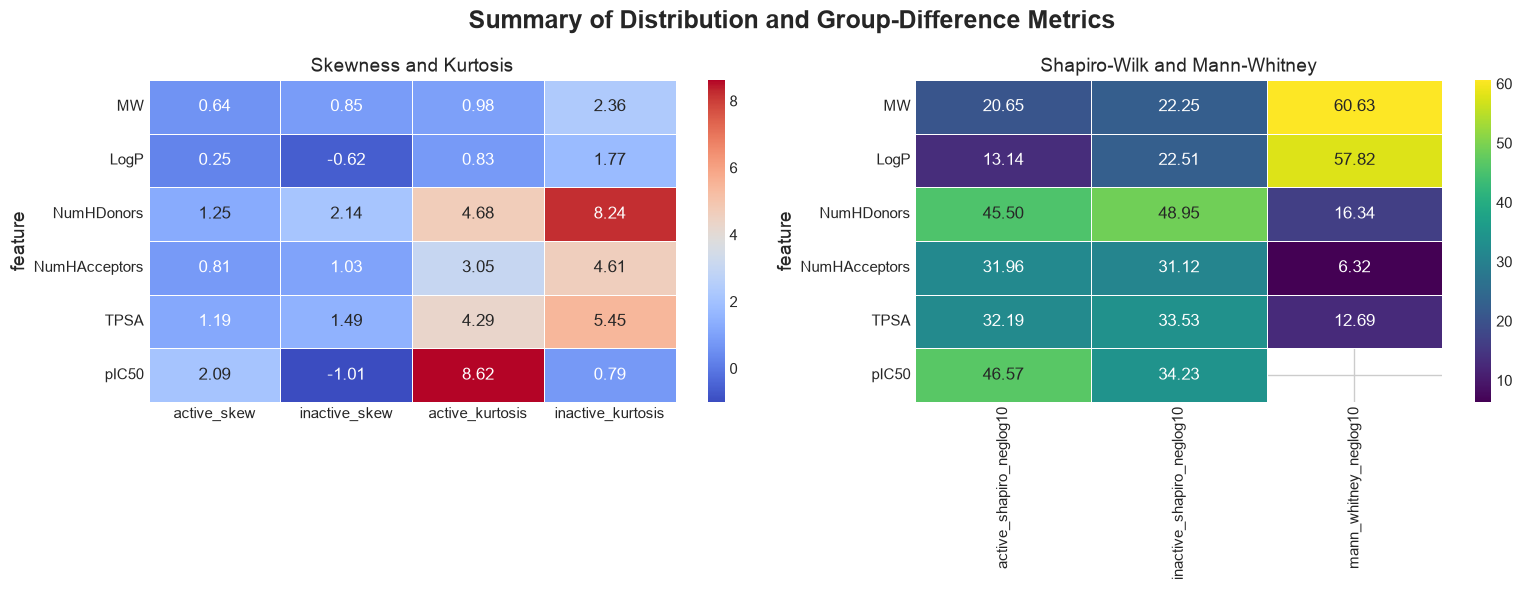

In [64]:
import numpy as np

features = ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'pIC50']
active = df3[df3['class'] == 'active']
inactive = df3[df3['class'] == 'inactive']

rows = []

for feat in features:
    a = active[feat].dropna()
    i = inactive[feat].dropna()

    active_skew = a.skew() if len(a) > 2 else np.nan
    inactive_skew = i.skew() if len(i) > 2 else np.nan

    active_kurt = a.kurt() if len(a) > 3 else np.nan
    inactive_kurt = i.kurt() if len(i) > 3 else np.nan

    active_shapiro_p = stats.shapiro(a).pvalue if len(a) >= 3 else np.nan
    inactive_shapiro_p = stats.shapiro(i).pvalue if len(i) >= 3 else np.nan

    mann_whitney_p = (
        stats.mannwhitneyu(a, i, alternative='two-sided').pvalue
        if len(a) >= 1 and len(i) >= 1 else np.nan
    )

    rows.append({
        'feature': feat,
        'active_skew': active_skew,
        'inactive_skew': inactive_skew,
        'active_kurtosis': active_kurt,
        'inactive_kurtosis': inactive_kurt,
        'active_shapiro_p': active_shapiro_p,
        'inactive_shapiro_p': inactive_shapiro_p,
        'mann_whitney_p': mann_whitney_p
    })

summary = pd.DataFrame(rows).set_index('feature')

summary['active_shapiro_neglog10'] = -np.log10(summary['active_shapiro_p'].replace(0, np.nan))
summary['inactive_shapiro_neglog10'] = -np.log10(summary['inactive_shapiro_p'].replace(0, np.nan))
summary['mann_whitney_neglog10'] = -np.log10(summary['mann_whitney_p'].replace(0, np.nan))

plot_df_1 = summary[['active_skew', 'inactive_skew', 'active_kurtosis', 'inactive_kurtosis']]
plot_df_2 = summary[['active_shapiro_neglog10', 'inactive_shapiro_neglog10', 'mann_whitney_neglog10']]

plt.figure(figsize=(16, 6))
plt.suptitle('Summary of Distribution and Group-Difference Metrics', fontsize=18, fontweight='bold')

plt.subplot(1, 2, 1)
sns.heatmap(plot_df_1, annot=True, fmt='.2f', cmap='coolwarm', linecolor='white', linewidths=0.5, cbar=True)
plt.title('Skewness and Kurtosis')

plt.subplot(1, 2, 2)
sns.heatmap(plot_df_2, annot=True, fmt='.2f', cmap='viridis', linecolor='white', linewidths=0.5, cbar=True)
plt.title('Shapiro-Wilk and Mann-Whitney')

plt.tight_layout()
plt.show()


### Skewness (is the distribution is lopsided).
Around 0: roughly symmetric.
Positive: longer right tail (more high values).
Negative: longer left tail (more low values).
Values far from 0 suggest non-normality.

### Kurtosis (how heavy-tailed or peaked the distribution is).
Around 3 (or close to 0 if using excess kurtosis): similar to a normal distribution.
Greater than 3: more outliers / heavier tails / sharper peak.
Less than 3: flatter distribution with lighter tails.

### Mann–Whitney U test
Compares the distribution of a variable between two groups, here active vs inactive.
Null hypothesis: both groups come from the same distribution.
Small p-value (typically < 0.05): evidence that the groups differ.
Large p-value: no strong evidence of a difference.

### Interpretation:

If skewness or kurtosis is far from the normal reference values, the variable may not be well approximated by a Gaussian distribution.
If the Mann–Whitney p-value is small, the active and inactive groups differ in that descriptor.
If the p-value is large, the groups look similar for that variable.
A practical rule of thumb:

Skewness near 0 and kurtosis near 3 suggest more Gaussian-like behavior.
Mann–Whitney significance suggests the groups differ, but it does not tell you whether the difference is large or small, only that it is statistically detectable.

### Interpretation of the results:

Skewness describes the asymmetry of the distribution. A value close to 0 suggests a fairly symmetric distribution, while positive or negative values indicate a longer tail on the right or left, respectively. Large absolute skewness values suggest the variable is not well approximated by a Gaussian distribution.
Kurtosis describes the shape of the distribution, especially the presence of extreme values. A value near 3 suggests a distribution similar to a normal one, while values much larger than 3 indicate a sharper peak with heavier tails, and values much smaller than 3 indicate a flatter distribution.
The Mann–Whitney U test compares the distribution of a variable between the active and inactive groups. A p-value below 0.05 suggests that the two groups differ significantly for that variable, whereas a p-value above 0.05 suggests no strong evidence of a difference.
In summary, skewness and kurtosis help you assess whether each descriptor looks Gaussian-like, while the Mann–Whitney test tells you whether the active and inactive groups differ in that descriptor.